1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


2.1 Creating Datasets

In [2]:
# Generate 2000 non-linear samples
X, y = make_moons(
    n_samples=2000,
    noise=0.12,
    random_state=42
)

# Create DataFrame in the same format as your image
df = pd.DataFrame({
    'X': X[:, 0],
    'Y': X[:, 1],
    'Class': y.astype(float)
})

df.head()

,X,Y,Class
0,1.750613,0.215969,1.0
1,0.388455,0.937320,0.0
2,0.494370,-0.308781,1.0
3,-0.947407,0.137360,0.0
4,0.504882,-0.348035,1.0


2.2 Visualize the Dataset

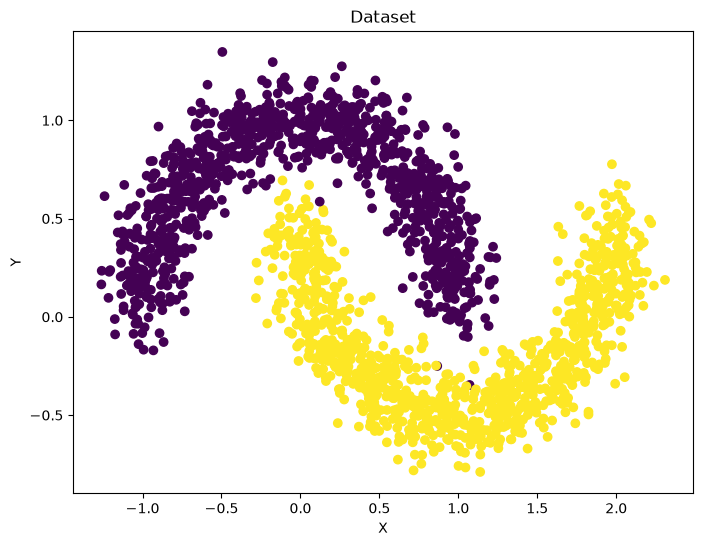

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['X'],
    df['Y'],
    c=df['Class']
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset')
plt.show()

3. Separate Features and Target

In [4]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 2)
y shape: (2000,)


4. Create Neural Network with tanh

In [5]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5. Model Summary

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

6. Check Initial Weights

In [7]:
model.get_weights()

[array([[-0.31064755, -0.44189066,  0.17454171,  0.12525064,  0.13822347,
         -0.6600888 ,  0.38551635,  0.27474958, -0.42345476,  0.05276871],
        [-0.38667086, -0.15906745, -0.18357784,  0.02678126,  0.42299908,
         -0.30146375,  0.5733797 ,  0.15777856, -0.00677621, -0.684788  ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.39351195,  0.07778597,  0.18358058,  0.19104719,  0.1401509 ,
         -0.45295385,  0.21216351, -0.46989194, -0.28630313,  0.00548178],
        [-0.3118298 ,  0.4372425 ,  0.36839402,  0.48507333,  0.47218287,
         -0.52682024, -0.5115764 ,  0.14320326,  0.388561  ,  0.30776423],
        [ 0.38640177,  0.37085277, -0.12265447,  0.500649  ,  0.4476993 ,
          0.31262898, -0.27971786,  0.4600141 , -0.01548427,  0.18807477],
        [-0.00130063,  0.1602509 ,  0.2903551 ,  0.18203104, -0.3899805 ,
         -0.16016042,  0.51983464, -0.35685745, -0.30345353, -0.01584822],
        [ 0.54655

7. Store the Weights

In [8]:
initial_weights = model.get_weights()

8. Random Weight Initialization with Zero Bias Initialization

In [9]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

9. Set the Initialized Weights and Biases in the Model

In [10]:
model.set_weights(initial_weights)

In [11]:
model.get_weights()

[array([[-0.68167335,  0.0776793 , -0.363182  , -0.2514918 , -0.67660266,
         -0.30452567,  1.4958764 ,  0.3301824 ,  0.90573376,  0.2879975 ],
        [ 0.5143227 ,  0.5326138 , -1.4665322 ,  0.3369938 ,  0.6077563 ,
          0.5556408 ,  0.8465364 , -0.36842555,  0.09055869, -0.90713876]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.02145337,  0.44021556, -0.16586392,  0.38094962,  0.08882142,
          0.28206265,  0.4680744 , -0.07951549, -0.4151991 ,  0.36472598],
        [-0.3586416 ,  0.5708071 , -0.08325463,  0.6506261 , -0.2807392 ,
         -0.3037823 ,  0.12404805,  0.45447674, -0.19971558, -0.3358788 ],
        [ 0.55653465, -0.07601935, -0.27409604, -0.37960547, -0.10952199,
         -0.39211875,  0.08852547, -0.63842756, -0.3668343 ,  0.30478814],
        [-0.08870271,  0.01487356,  0.04196956,  0.00890644,  0.11226885,
          0.09070461, -0.12265067,  0.25451335,  0.02338062, -0.01282553],
        [ 0.17592

10. Compile the Model

In [12]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

11. Train the Model

In [13]:
history = model.fit(
    X,
    y,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6731 - loss: 0.6271 - val_accuracy: 0.7725 - val_loss: 0.5082
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.4449 - val_accuracy: 0.8625 - val_loss: 0.3723
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3462 - val_accuracy: 0.8875 - val_loss: 0.3134
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8775 - loss: 0.3103 - val_accuracy: 0.8975 - val_loss: 0.2881
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8825 - loss: 0.2973 - val_accuracy: 0.9000 - val_loss: 0.2767
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8838 - loss: 0.2876 - val_accuracy: 0.9000 - val_loss: 0.2683
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8888 - loss: 0.2780 - val_accuracy: 0.9025 - val_loss: 0.2540
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.2645 - val_accuracy: 0.9100 - v

12. Check the Weights After Training

In [14]:
model.get_weights()

[array([[-0.49120638,  0.214566  , -0.6753612 , -0.33554032, -0.64710927,
         -0.39198226,  2.0904727 ,  0.3594231 ,  1.0920761 ,  0.12873127],
        [ 0.37041602,  0.24012046, -1.2659867 ,  0.22735138,  0.6944376 ,
          0.165845  ,  0.3450732 , -0.1547929 , -0.12845077, -0.96984065]],
       dtype=float32),
 array([ 0.23702037,  0.04220226,  0.00240028, -0.01994853, -0.27812156,
         0.40989545, -0.822157  , -0.04191793,  0.23503342,  0.23101705],
       dtype=float32),
 array([[-0.12279956,  0.51170045, -0.12584679,  0.1708245 ,  0.06780776,
          0.3442474 ,  0.5546293 , -0.25016418, -0.5801826 ,  0.61356163],
        [-0.29918277,  0.54464895,  0.05318848,  0.63030446, -0.3710926 ,
         -0.353103  ,  0.09605871,  0.33698145, -0.17905563, -0.46229026],
        [ 0.5402416 , -0.09808784, -0.38243994, -0.41436586, -0.10800059,
         -0.40737006,  0.05862664, -0.58495426, -0.33750993,  0.46985638],
        [-0.29836228,  0.15504535,  0.09825312, -0.41974586, 

13. Check the Predictions

In [15]:
predictions = model.predict(X, verbose=0)

predictions[:10]

array([[9.9860901e-01],
       [1.3846687e-04],
       [9.9983710e-01],
       [1.7428325e-04],
       [9.9983943e-01],
       [9.9985176e-01],
       [1.9781775e-04],
       [9.9949718e-01],
       [1.7659504e-04],
       [9.9982911e-01]], dtype=float32)

14. Plot Training Loss

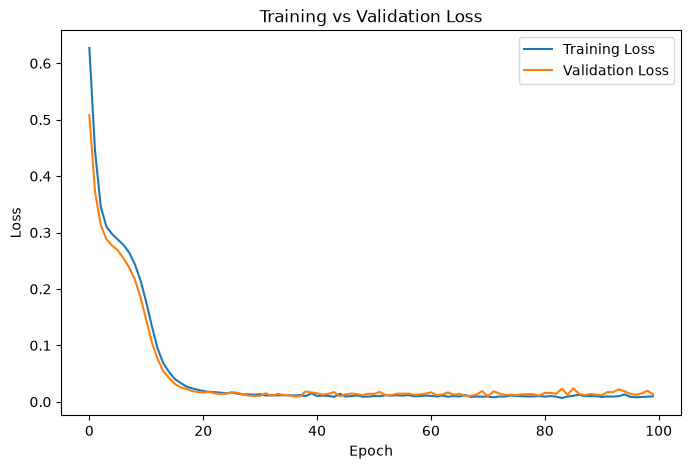

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

15. Plot Accuracy

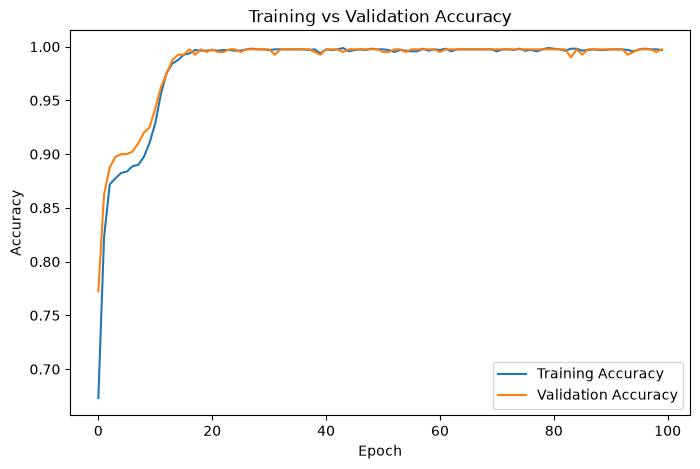

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

16. Decision Boundary

In [18]:
from mlxtend.plotting import plot_decision_regions

class MyModel:

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(
            X,
            verbose=0
        )

        return (
            pred >= 0.5
        ).astype(int).ravel()

17. Create Classifier

In [19]:
clf = MyModel(model)

18. Plot Decision Regions

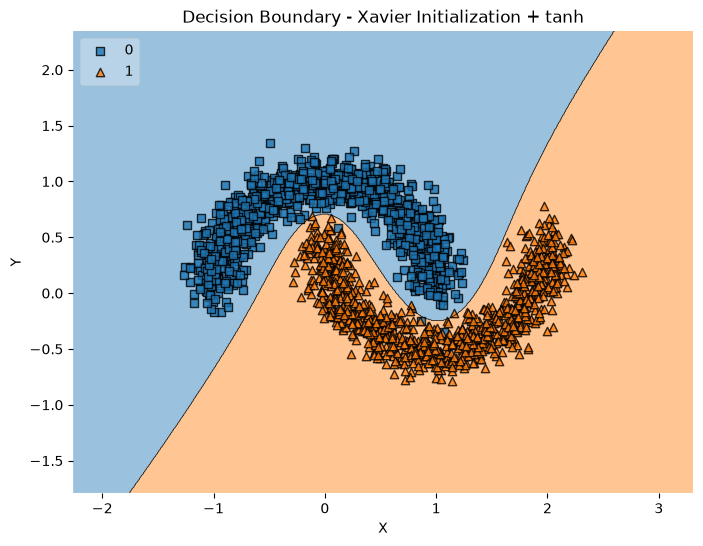

In [20]:
plt.figure(figsize=(8, 6))

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Boundary - Xavier Initialization + tanh')

plt.show()

In [21]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.024601935827615714)

In [22]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.028973644127736776)